# Import libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load dataset

In [4]:
df = pd.read_csv("bee_dataset(1).csv")
df

,rainfall_mm,avg_temperature,humidity,num_hives,hive_type,colony_strength,disease_status,experience_years,inspection_frequency,honey_yield_kg
0,859.605698,28.852355,83.993554,40,modern,medium,yes,11,1,2802.221569
1,783.408284,30.818833,79.246337,28,traditional,medium,no,15,1,2554.859644
2,877.722625,24.202865,70.596304,58,traditional,weak,yes,16,9,3382.549193
3,982.763583,28.125938,63.530632,55,traditional,medium,no,17,6,3568.241945
4,771.901595,25.698715,76.982233,28,modern,strong,no,2,5,2522.913516
...,...,...,...,...,...,...,...,...,...,...
495,864.669205,26.437799,90.060929,38,traditional,medium,no,2,4,2814.331600
496,675.530461,30.595373,90.615036,31,modern,weak,no,12,1,2678.035597
497,777.159359,28.281686,82.083662,49,traditional,medium,yes,1,7,2858.384527
498,694.925810,25.857642,80.240625,30,traditional,medium,yes,8,2,2224.454624


# Data Preprocessing

In [5]:
df.isnull().sum()

rainfall_mm             0
avg_temperature         0
humidity                0
num_hives               0
hive_type               0
colony_strength         0
disease_status          0
experience_years        0
inspection_frequency    0
honey_yield_kg          0
dtype: int64

# Encode categorical variables

In [7]:
df_encoded = pd.get_dummies(df, columns=['hive_type','colony_strength','disease_status'], drop_first=True)
df_encoded

,rainfall_mm,avg_temperature,humidity,num_hives,experience_years,inspection_frequency,honey_yield_kg,hive_type_traditional,colony_strength_strong,colony_strength_weak,disease_status_yes
0,859.605698,28.852355,83.993554,40,11,1,2802.221569,False,False,False,True
1,783.408284,30.818833,79.246337,28,15,1,2554.859644,True,False,False,False
2,877.722625,24.202865,70.596304,58,16,9,3382.549193,True,False,True,True
3,982.763583,28.125938,63.530632,55,17,6,3568.241945,True,False,False,False
4,771.901595,25.698715,76.982233,28,2,5,2522.913516,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
495,864.669205,26.437799,90.060929,38,2,4,2814.331600,True,False,False,False
496,675.530461,30.595373,90.615036,31,12,1,2678.035597,False,False,True,False
497,777.159359,28.281686,82.083662,49,1,7,2858.384527,True,False,False,True
498,694.925810,25.857642,80.240625,30,8,2,2224.454624,True,False,False,True


# Features and target

In [8]:
X = df_encoded.drop("honey_yield_kg", axis=1)
y = df_encoded["honey_yield_kg"]

In [11]:
X

,rainfall_mm,avg_temperature,humidity,num_hives,experience_years,inspection_frequency,hive_type_traditional,colony_strength_strong,colony_strength_weak,disease_status_yes
0,859.605698,28.852355,83.993554,40,11,1,False,False,False,True
1,783.408284,30.818833,79.246337,28,15,1,True,False,False,False
2,877.722625,24.202865,70.596304,58,16,9,True,False,True,True
3,982.763583,28.125938,63.530632,55,17,6,True,False,False,False
4,771.901595,25.698715,76.982233,28,2,5,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
495,864.669205,26.437799,90.060929,38,2,4,True,False,False,False
496,675.530461,30.595373,90.615036,31,12,1,False,False,True,False
497,777.159359,28.281686,82.083662,49,1,7,True,False,False,True
498,694.925810,25.857642,80.240625,30,8,2,True,False,False,True


In [12]:
y

0      2802.221569
1      2554.859644
2      3382.549193
3      3568.241945
4      2522.913516
          ...     
495    2814.331600
496    2678.035597
497    2858.384527
498    2224.454624
499    2699.064147
Name: honey_yield_kg, Length: 500, dtype: float64

# Train-test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X_train

,rainfall_mm,avg_temperature,humidity,num_hives,experience_years,inspection_frequency,hive_type_traditional,colony_strength_strong,colony_strength_weak,disease_status_yes
249,848.597805,24.186678,54.441044,49,19,7,False,False,True,True
433,886.105071,22.602388,64.169226,26,17,4,False,False,False,False
19,630.523556,28.502774,74.241659,42,4,6,True,True,False,False
322,701.813518,31.597796,69.295012,30,18,1,False,False,False,True
332,809.096547,24.991718,67.865571,30,9,8,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...
106,1026.342308,25.452422,76.127739,22,18,5,False,False,False,False
270,972.952795,28.415504,80.913101,46,13,4,True,True,False,False
348,713.786693,25.724520,56.331213,53,13,5,True,True,False,False
435,808.891374,25.995892,72.825800,18,3,6,True,False,False,False


In [15]:
X_test

,rainfall_mm,avg_temperature,humidity,num_hives,experience_years,inspection_frequency,hive_type_traditional,colony_strength_strong,colony_strength_weak,disease_status_yes
361,983.928670,23.968512,75.792915,37,17,6,True,False,True,False
73,987.757239,26.561799,57.170078,48,17,8,False,False,False,False
374,1058.381895,26.933746,84.711703,47,19,3,True,False,True,False
155,714.277830,27.118437,80.098171,51,11,5,True,False,False,False
104,780.645715,27.826870,81.081828,51,11,9,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
347,631.104347,31.910600,79.343199,14,1,1,True,False,True,True
86,909.848254,26.081278,80.302835,34,2,5,True,False,True,False
75,898.628301,22.577729,65.062434,44,15,7,False,True,False,False
438,595.594107,27.487601,74.909750,23,12,5,False,True,False,False


In [16]:
y_train

249    3001.129568
433    2381.358299
19     2797.837414
322    2622.664480
332    2552.743163
          ...     
106    2642.024641
270    3466.383500
348    3346.011144
435    2168.611530
102    2561.987282
Name: honey_yield_kg, Length: 400, dtype: float64

In [17]:
y_test

361    2890.302927
73     3435.568638
374    3436.153450
155    3134.439735
104    3339.192067
          ...     
347    1603.519687
86     2647.547747
75     3201.224676
438    2576.438368
15     3063.760255
Name: honey_yield_kg, Length: 100, dtype: float64

# Train Linear Regression

In [18]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [19]:
lr_model

LinearRegression()

In [20]:
y_pred_lr

array([2888.56005052, 3447.63377694, 3344.95453844, 3214.41329971,
       3473.31180404, 3017.16728435, 3165.59150748, 2806.9604458 ,
       3084.56260192, 3138.60966074, 3112.33043575, 2830.27970123,
       2598.7104648 , 2654.27372208, 2155.67802493, 2220.12986077,
       2816.63541115, 2330.75942022, 2593.13590652, 2148.69724314,
       3386.51420825, 2421.83965816, 3053.06100262, 2331.38583741,
       2192.41705565, 1909.07397607, 2837.28732299, 2955.5058966 ,
       2261.64592627, 2750.42239648, 2173.96251734, 2294.66991887,
       3151.86529875, 2891.54442881, 3181.25115617, 2754.20373845,
       2415.96422418, 2545.34256454, 3152.81994082, 2645.53976794,
       2279.598397  , 2973.06945356, 3390.66259759, 3691.7968957 ,
       2646.53809618, 2509.5183675 , 2886.49776465, 3025.69085117,
       2670.53722189, 2377.07392778, 3246.02690294, 1988.41475239,
       2177.51538517, 3000.61745766, 2157.58507414, 2501.59869958,
       3058.68204111, 3378.51183718, 2008.98903622, 2953.33371

# Train Decision Tree

In [21]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [22]:
dt_model

DecisionTreeRegressor(max_depth=5, random_state=42)

In [23]:
y_pred_dt

array([3005.85999556, 3375.42636432, 3046.80688881, 3191.14810376,
       3191.14810376, 3046.80688881, 3046.80688881, 2514.33353864,
       3046.80688881, 3191.14810376, 3005.85999556, 3046.80688881,
       3005.85999556, 2830.68610111, 2028.04692424, 1901.50120833,
       2720.42736674, 2625.10256249, 2344.33767589, 2274.567262  ,
       3375.42636432, 2514.33353864, 3046.80688881, 2514.33353864,
       2028.04692424, 1979.67623421, 2892.20039767, 3005.85999556,
       2514.33353864, 2720.42736674, 2028.04692424, 2274.567262  ,
       3046.80688881, 2953.66426539, 3184.3251755 , 2720.42736674,
       2514.33353864, 2720.42736674, 2720.42736674, 2830.68610111,
       2121.6414272 , 2720.42736674, 3375.42636432, 3356.07613259,
       2720.42736674, 2625.10256249, 2676.72504411, 3046.80688881,
       2514.33353864, 2456.48207954, 3184.3251755 , 1979.67623421,
       2225.50889593, 2720.42736674, 2225.50889593, 2514.33353864,
       2720.42736674, 3184.3251755 , 2514.33353864, 3046.80688

# Evaluate models

In [24]:
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))

Linear Regression R2: 0.961757727242956
Linear Regression MSE: 9099.930800784008


In [25]:
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))
print("Decision Tree MSE:", mean_squared_error(y_test, y_pred_dt))

Decision Tree R2: 0.8302569398042466
Decision Tree MSE: 40391.16899531444


# Compare and select best model

In [26]:
if r2_score(y_test, y_pred_dt) > r2_score(y_test, y_pred_lr):
    best_model = dt_model
    print("Best model: Decision Tree")
else:
    best_model = lr_model
    print("Best model: Linear Regression")

Best model: Linear Regression


# Visualizations

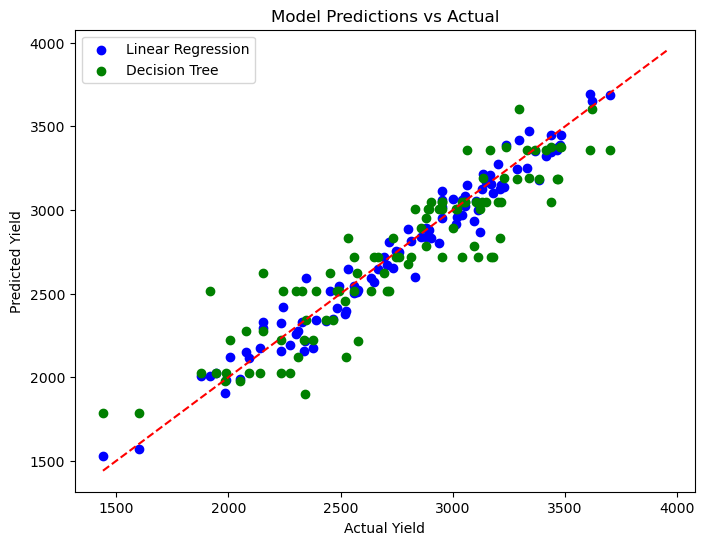

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, color='blue', label='Linear Regression')
plt.scatter(y_test, y_pred_dt, color='green', label='Decision Tree')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.legend()
plt.title("Model Predictions vs Actual")
plt.show()